Get the prob distribution for the time it takes until one person has recovered or been infected

In [1]:
import numpy as np
from matplotlib import pyplot as plt

Infection times for bn=0.1, dn=0.2: Mean = 10.049, Std = 10.096
Recovery times for bn=0.1, dn=0.2: Mean = 5.032, Std = 5.060
Gradient for infection times (bn=0.1, dn=0.2): -0.092


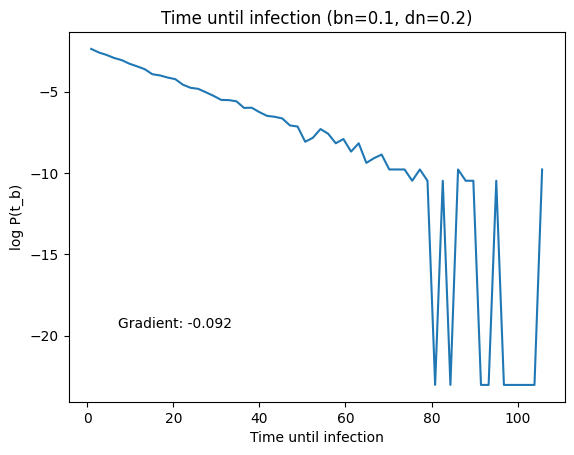

Gradient for recovery times (bn=0.1, dn=0.2): -0.182


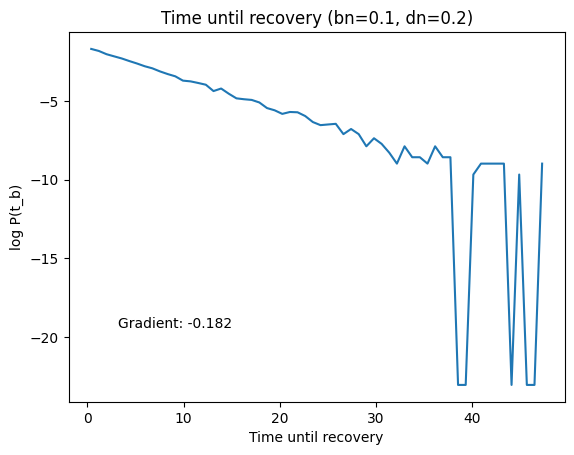

Infection times for bn=1, dn=2: Mean = 0.987, Std = 0.990
Recovery times for bn=1, dn=2: Mean = 0.495, Std = 0.495
Gradient for infection times (bn=1, dn=2): -0.959


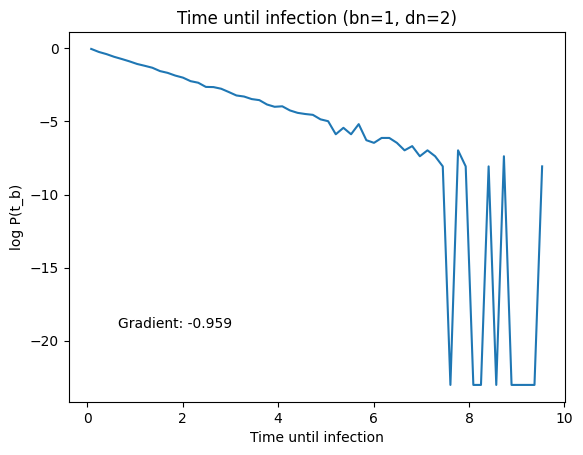

Gradient for recovery times (bn=1, dn=2): -1.813


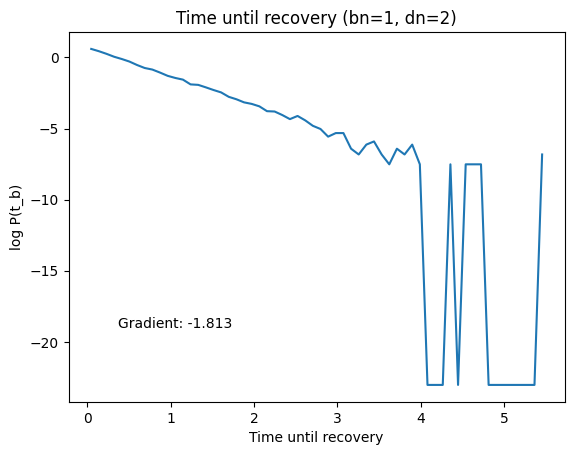

Infection times for bn=10, dn=5: Mean = 0.100, Std = 0.101
Recovery times for bn=10, dn=5: Mean = 0.200, Std = 0.202
Gradient for infection times (bn=10, dn=5): -9.257


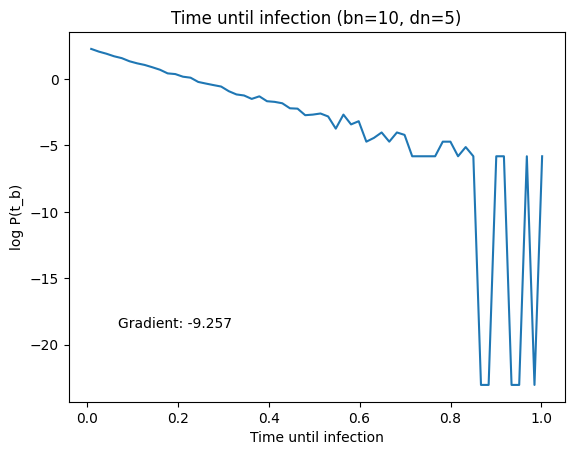

Gradient for recovery times (bn=10, dn=5): -4.522


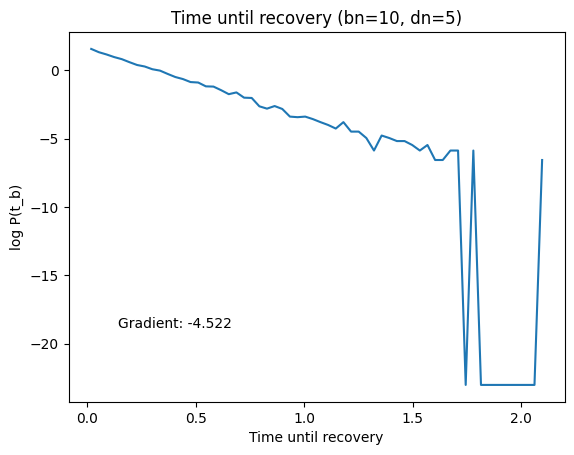

In [14]:
start_infected = 100
list_values = [[0.1, 0.2], [1, 2], [10, 5]]
dt = 0.001

number_of_repititions = 20000


def plot_graph(local_times, event, bn, dn):
    counts, bin_edges = np.histogram(local_times, bins = 60, density=True)
    counts = np.where(counts == 0, 1e-10, counts)

    bin_center = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    log_counts = np.log(counts)

    valid = counts > 1e-6
    gradient = np.polyfit(bin_center[valid], log_counts[valid], 1)[0]

    print(f"Gradient for {event} times (bn={bn}, dn={dn}): {gradient:.3f}")

    fig, ax = plt.subplots()
    ax.plot(bin_center, log_counts)
    ax.set_title(f"Time until {event} (bn={bn}, dn={dn})")
    ax.set_xlabel(f"Time until {event}")
    ax.set_ylabel("log P(t_b)")
    ax.text(0.1, 0.2, f"Gradient: {gradient:.3f}", transform =ax.transAxes)
    plt.show()


def find_time_to_event(bn, dn, dt, number_of_repititions):
    prob_another_infection = bn * dt
    prob_another_recovery = dn * dt

    infection_times_local = []
    recovery_times_local = []

    for idx in range(number_of_repititions):
        infection_found = True
        recovery_found = True
        j = 1
        while True:
            if np.random.rand() < prob_another_infection:
                infection_times_local.append(j * dt)
                break
            j += 1
        j=1
        while True:
            if np.random.rand() < prob_another_recovery:
                recovery_times_local.append(j * dt)
                break
            j += 1
    
    print(f"Infection times for bn={bn}, dn={dn}: Mean = {np.mean(infection_times_local):.3f}, Std = {np.std(infection_times_local):.3f}")
    print(f"Recovery times for bn={bn}, dn={dn}: Mean = {np.mean(recovery_times_local):.3f}, Std = {np.std(recovery_times_local):.3f}")
    
    return infection_times_local, recovery_times_local



time_to_infection_list = []
time_to_recovery_list = []
for i, values in enumerate(list_values):
    loc_infection, loc_recovery = find_time_to_event(list_values[i][0], list_values[i][1], dt, number_of_repititions)
    time_to_infection_list.append(loc_infection)
    time_to_recovery_list.append(loc_recovery)
    plot_graph(loc_infection, "infection", list_values[i][0], list_values[i][1])
    plot_graph(loc_recovery, "recovery", list_values[i][0], list_values[i][1])




In [15]:
def plot_graph_over_population(local_times, bn, dn, t):
    counts, bin_edges = np.histogram(local_times, bins = 60, density=True)
    counts = np.where(counts == 0, 1e-10, counts)

    bin_center = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    neg_log_counts =  -np.log(counts)


    gradient = np.polyfit(bin_center, neg_log_counts, 1)[0]

    print(f"Gradient for {t} time (bn={bn}, dn={dn}): {gradient:.3f}")

    fig, ax = plt.subplots()
    ax.plot(bin_center, neg_log_counts)
    ax.set_title(f"Num of sick at time= {t} (bn={bn}, dn={dn})")
    ax.set_xlabel(f"Num of sick")
    ax.set_ylabel("log P(n_{t})")
    ax.text(0.1, 0.2, f"Gradient: {gradient:.3f}", transform = ax.transAxes)
    plt.show()

In [ ]:
#From the previous code, we know that:
# t = - (ln(r))/ rate
#Where rate is bn for infection and dn for recovery and r is a random number

In [ ]:
def developing_system(alpha, beta, N,t):
    n_list = []

    num_iterations = 1000

    n0 = int(N*((alpha - beta)/alpha))

    for i in range(num_iterations):
        n = n0
        cur_time = 0
        while cur_time < t:
            if n == 0:
                break
            bn = alpha * n * (1 - n/N)
            dn = beta * n

            
            time_to_infection = -np.log(np.random.rand())/bn
            time_to_recovery = -np.log(np.random.rand())/dn
            time_to_event = min(time_to_infection, time_to_recovery)
            cur_time += time_to_event
            if time_to_infection < time_to_recovery:
                n += 1
            else:
                n-= 1
            
        
        n_list.append(n)
    
    plot_graph_over_population(n_list, bn, dn, t)
    

        
    



    



In [ ]:
alpha = 0.5
beta = 0.1
N = 100000
n0 = int(N*((alpha - beta)/alpha))

bn = alpha * n0 * (1 - n0/N)
dn = beta * n0

infection_time_for_T_ext, recovery_time_for_T_ext = find_time_to_event(bn, dn, dt, number_of_repititions=10000)

#Find T_Ext
num_trials = 500
T_ext_list = np.zeros(num_trials)
for i in range(num_trials):
    n = n0
    cur_time = 0
    while n>0 and cur_time < 1e6:
        t_infect = np.random.choice(infection_time_for_T_ext)
        t_recover = np.random.choice(recovery_time_for_T_ext)
        cur_time += min(t_infect, t_recover)
        if t_infect < t_recover:
            n += 1
        else:
            n -= 1
    T_ext_list[i] = cur_time

    if i % 50 == 0:
        print(f"Simulation {i*50}/500 completed")

T_ext = np.mean(T_ext_list)

Infection times for bn=7999.999999999998, dn=8000.0: Mean = 0.001, Std = 0.000
Recovery times for bn=7999.999999999998, dn=8000.0: Mean = 0.001, Std = 0.000


Gradient for 3 time (bn=8072.902319999998, dn=7975.6): -0.009


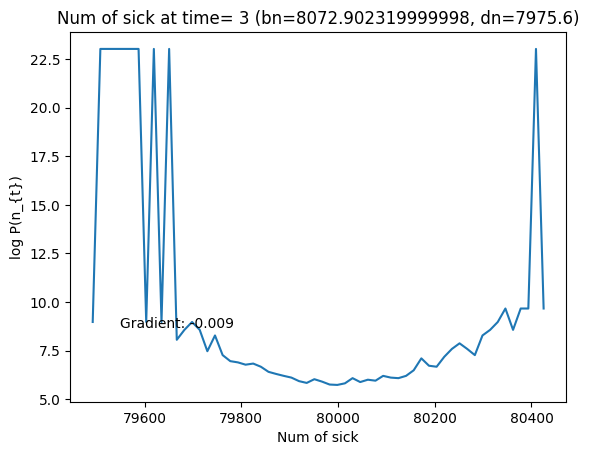

In [ ]:


developing_system(alpha, beta, N, 3)
developing_system(alpha, beta, N, 10)